In [1]:
import xarray as xr
import matplotlib.pyplot as plt
# from cmocean import cm 
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle

In [16]:
ds = xr.open_dataset(r'../data/amazon2.nc')

### Interpolation of Lower layers 

In [17]:
## interp lower layers
z_orig = ds.depth  # (depth,)
z_threshold = 1000  # metros

# Dividir en superficial y profundo
z_shallow = z_orig.where(z_orig < z_threshold, drop=True)
z_deep = z_orig.where(z_orig >= z_threshold, drop=True)

# Interpolar verticalmente duplicando puntos entre capas profundas
z_deep_mid = (z_deep.shift(depth=-1)+z_deep)/2 
z_deep_mid=z_deep_mid.dropna(dim='depth')

z_new = xr.concat([z_shallow,z_deep, z_deep_mid], dim='depth').sortby('depth')

zz = xr.DataArray(
    z_new.values,
    dims=["depth"],
    coords={"depth": z_new.values},
    name="depth"
)

zz.name = "depth"  # debe coincidir con el nombre del eje de profundidad en ds

# Interpolar uo y vo a la nueva malla de profundidad
uo_interp = ds.uo.interp(depth=zz)
vo_interp = ds.vo.interp(depth=zz)

ds= xr.Dataset({
    "uo": uo_interp,
    "vo": vo_interp
})

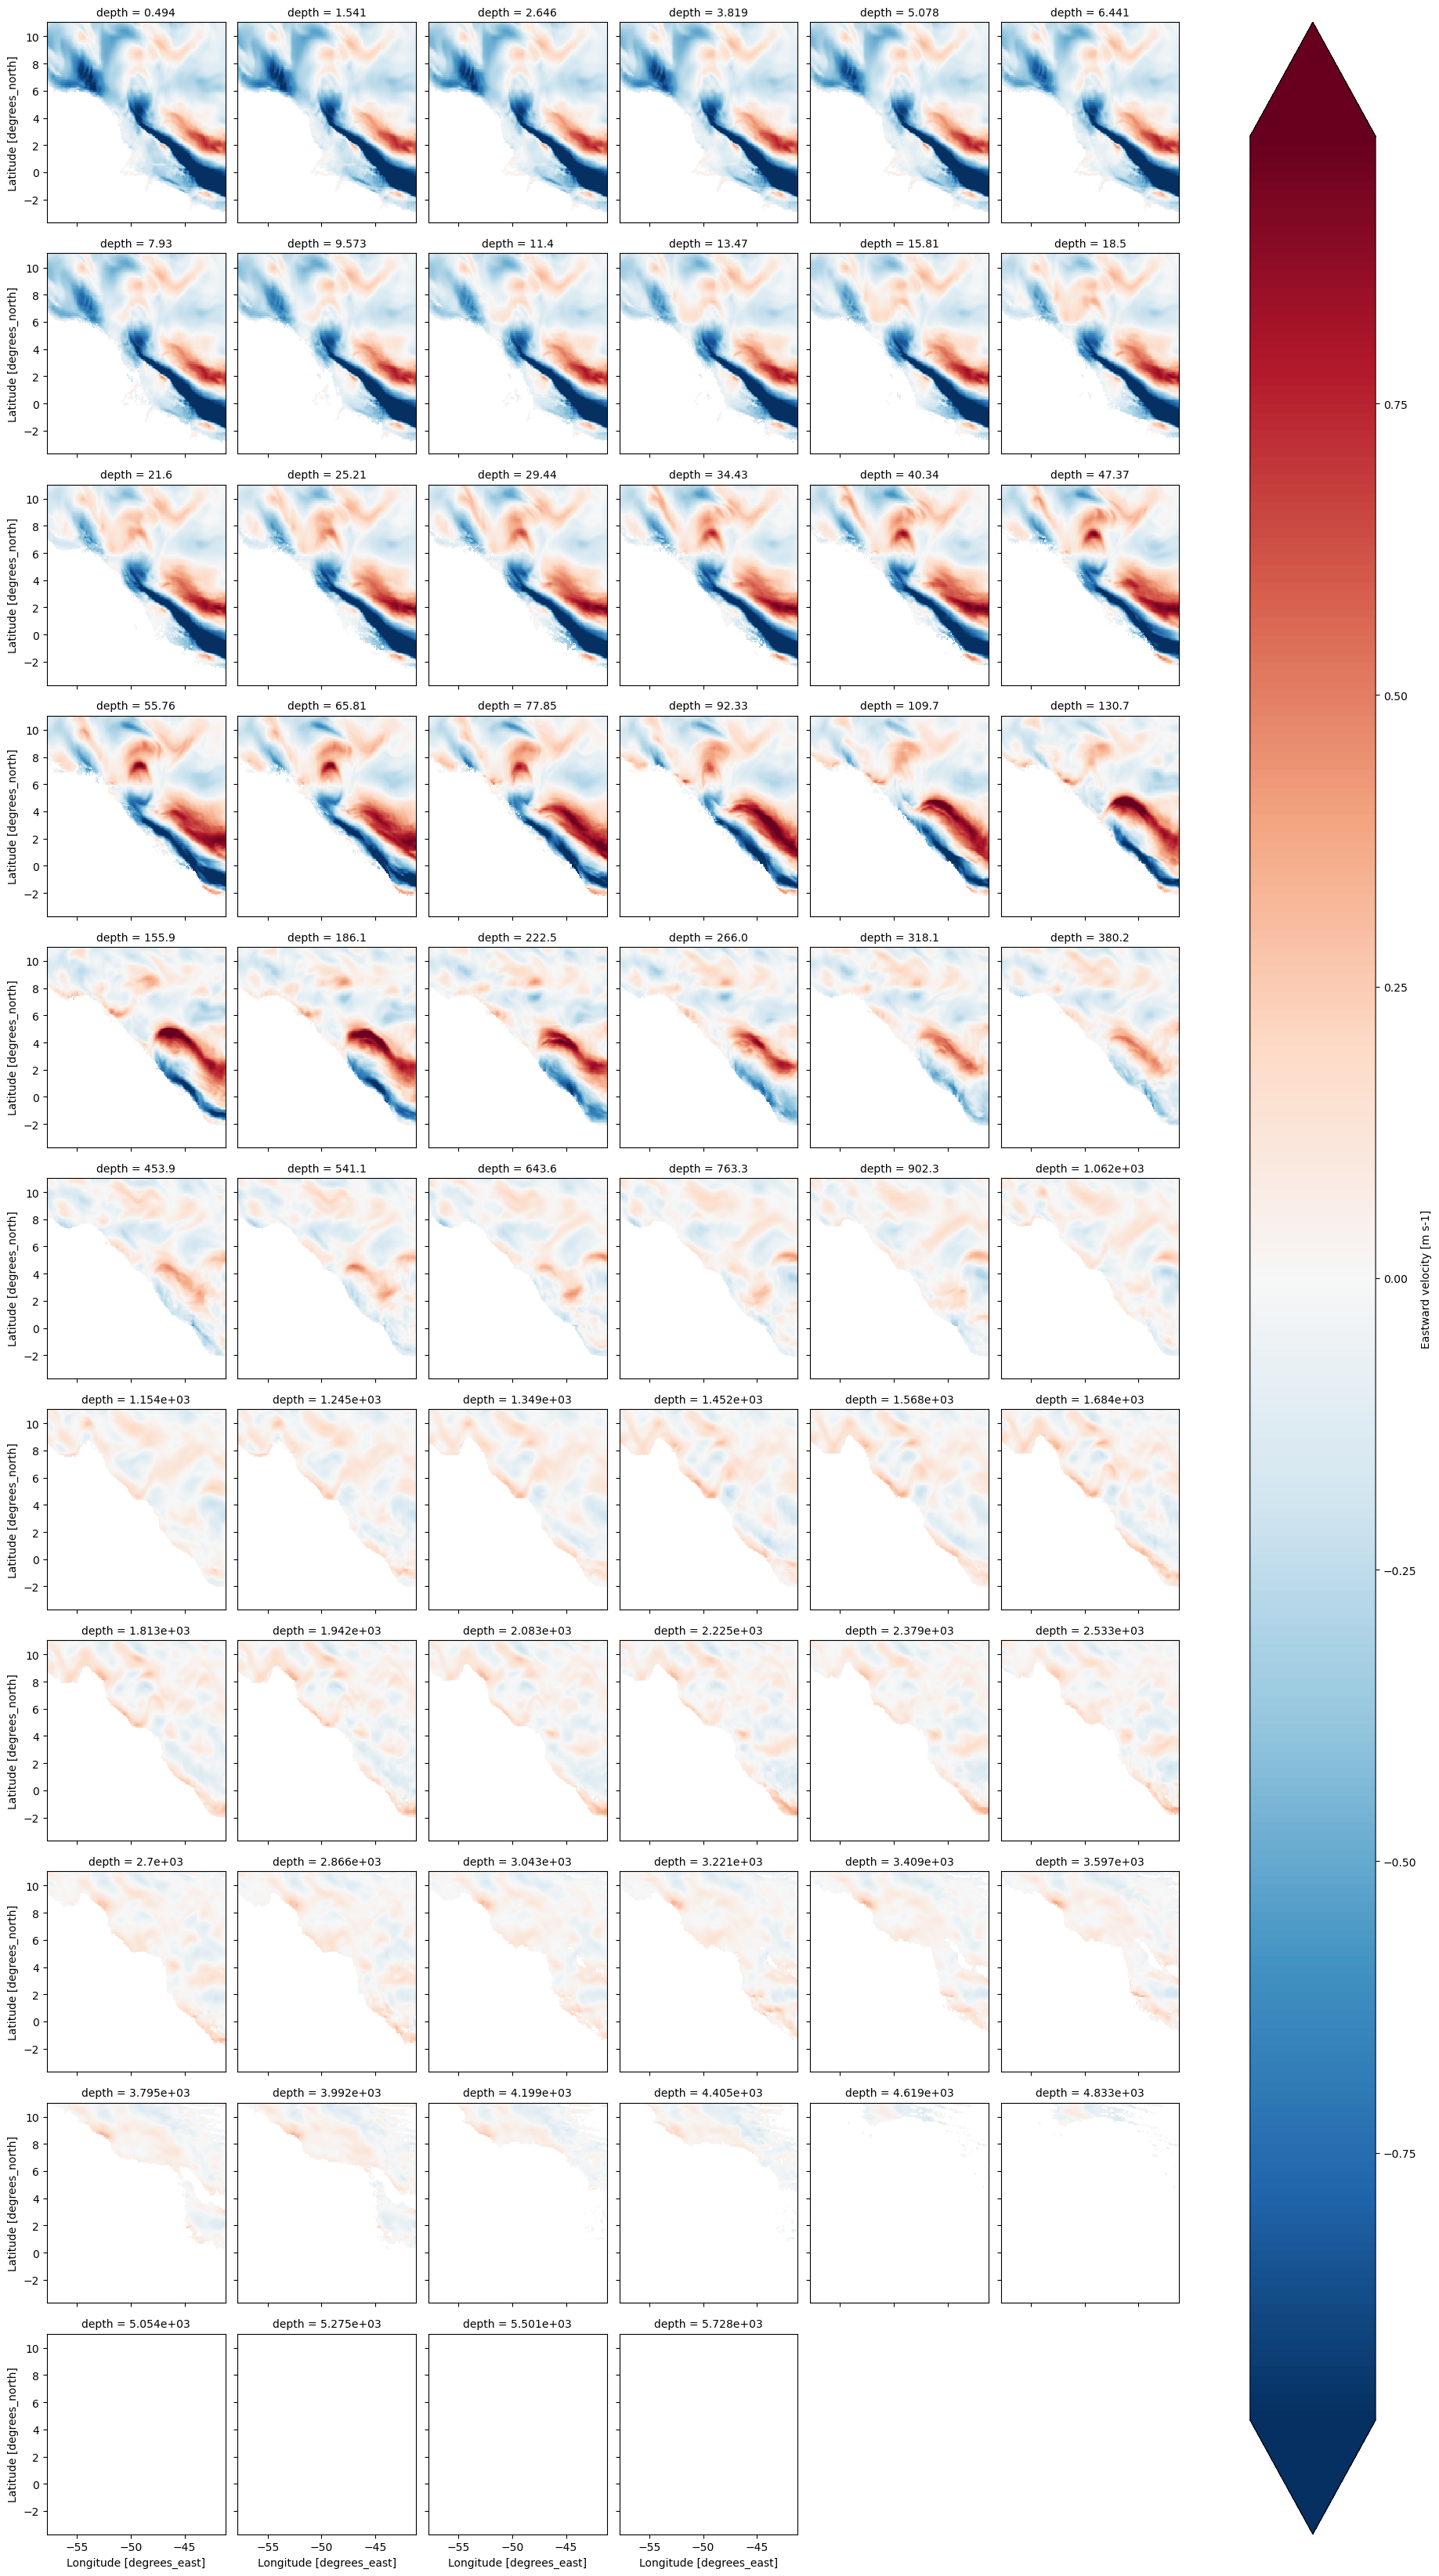

In [20]:
ds.uo.isel(time=0).plot(x='longitude',y='latitude',col='depth',col_wrap=6, robust=True)

### Mask Calculation

In [21]:
_lat = ds.latitude
_lon = ds.longitude
_zt = ds.depth

ds = ds.rename({"depth": "k", "latitude":"j", "longitude":"i"})
ds = ds.assign_coords(
    k=np.arange(ds.sizes["k"]),
    j=np.arange(ds.sizes["j"]),
    i=np.arange(ds.sizes["i"]),
    depth_t=("k", _zt.data),
    latitude_f = ("j", _lat.data),
    longitude_f = ("i", _lon.data),
)

ds = ds.rename({"uo":"uf", "vo":"vf"})
ds

<xarray.Dataset> Size: 180MB
Dimensions:      (time: 10, k: 64, j: 177, i: 199)
Coordinates:
  * time         (time) datetime64[ns] 80B 2021-06-01 2021-06-02 ... 2021-06-10
  * k            (k) int64 512B 0 1 2 3 4 5 6 7 8 ... 55 56 57 58 59 60 61 62 63
  * j            (j) int64 1kB 0 1 2 3 4 5 6 7 ... 170 171 172 173 174 175 176
  * i            (i) int64 2kB 0 1 2 3 4 5 6 7 ... 192 193 194 195 196 197 198
    depth_t      (k) float32 256B 0.494 1.541 2.646 ... 5.501e+03 5.728e+03
    latitude_f   (j) float32 708B -3.667 -3.583 -3.5 -3.417 ... 10.83 10.92 11.0
    longitude_f  (i) float32 796B -57.75 -57.67 -57.58 ... -41.42 -41.33 -41.25
Data variables:
    uf           (time, k, j, i) float32 90MB nan nan nan nan ... nan nan nan
    vf           (time, k, j, i) float32 90MB nan nan nan nan ... nan nan nan

### Calculate F and T mask

In [22]:
ds = ds.assign(fmask = ds.uf.isel(time=0,drop=True).notnull())

In [23]:
ds = ds.assign(
    tmask=(
        ds.fmask.shift(i=0,j=0)
        | ds.fmask.shift(i=-1,j=-1).fillna(False)
        | ds.fmask.shift(i=0, j=-1).fillna(False)
        | ds.fmask.shift(i=-1,j=-1).fillna(False)
    ).astype(bool)
)
ds

<xarray.Dataset> Size: 185MB
Dimensions:      (time: 10, k: 64, j: 177, i: 199)
Coordinates:
  * time         (time) datetime64[ns] 80B 2021-06-01 2021-06-02 ... 2021-06-10
  * k            (k) int64 512B 0 1 2 3 4 5 6 7 8 ... 55 56 57 58 59 60 61 62 63
  * j            (j) int64 1kB 0 1 2 3 4 5 6 7 ... 170 171 172 173 174 175 176
  * i            (i) int64 2kB 0 1 2 3 4 5 6 7 ... 192 193 194 195 196 197 198
    depth_t      (k) float32 256B 0.494 1.541 2.646 ... 5.501e+03 5.728e+03
    latitude_f   (j) float32 708B -3.667 -3.583 -3.5 -3.417 ... 10.83 10.92 11.0
    longitude_f  (i) float32 796B -57.75 -57.67 -57.58 ... -41.42 -41.33 -41.25
Data variables:
    uf           (time, k, j, i) float32 90MB nan nan nan nan ... nan nan nan
    vf           (time, k, j, i) float32 90MB nan nan nan nan ... nan nan nan
    fmask        (k, j, i) bool 2MB False False False ... False False False
    tmask        (k, j, i) bool 2MB False False False ... False False False

### Calculate U and V faces

In [24]:
ds = ds.assign(
    u=(ds.uf.fillna(0) + ds.uf.shift(j=-1).fillna(0)) /2,
    v=(ds.vf.fillna(0) + ds.vf.shift(i=-1).fillna(0)) /2,
)
ds

<xarray.Dataset> Size: 365MB
Dimensions:      (time: 10, k: 64, j: 177, i: 199)
Coordinates:
  * time         (time) datetime64[ns] 80B 2021-06-01 2021-06-02 ... 2021-06-10
  * k            (k) int64 512B 0 1 2 3 4 5 6 7 8 ... 55 56 57 58 59 60 61 62 63
  * j            (j) int64 1kB 0 1 2 3 4 5 6 7 ... 170 171 172 173 174 175 176
  * i            (i) int64 2kB 0 1 2 3 4 5 6 7 ... 192 193 194 195 196 197 198
    depth_t      (k) float32 256B 0.494 1.541 2.646 ... 5.501e+03 5.728e+03
    latitude_f   (j) float32 708B -3.667 -3.583 -3.5 -3.417 ... 10.83 10.92 11.0
    longitude_f  (i) float32 796B -57.75 -57.67 -57.58 ... -41.42 -41.33 -41.25
Data variables:
    uf           (time, k, j, i) float32 90MB nan nan nan nan ... nan nan nan
    vf           (time, k, j, i) float32 90MB nan nan nan nan ... nan nan nan
    fmask        (k, j, i) bool 2MB False False False ... False False False
    tmask        (k, j, i) bool 2MB False False False ... False False False
    u            (time, k, j, i) float32 90MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    v            (time, k, j, i) float32 90MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0

### Create Z_t

In [29]:
zt = ds.depth_t.data
zw = [zt[0]*2]


for k in range(1,len(zt)):
    zw.append((zt[k] - zw[k-1])*2 + zw[k-1])
print(*zw)

0.98805 2.0947 3.1966379 4.4423523 5.714096 7.1671324 8.691988 10.454006 12.355993 14.578287 17.041853 19.949266 23.248373 27.174448 31.715014 37.15329 43.534813 51.21257 60.31601 71.29852 84.40918 100.242966 119.21564 142.11636 169.58502 202.66617 242.28424 289.7964 346.45844 413.9676 493.90784 588.27 698.8635 827.80273 976.87585 1148.004 1159.7269 1330.8551 1366.6869 1537.8151 1598.7201 1769.848 1856.329 2027.4569 2139.5137 2310.642 2447.772 2618.9 2780.1392 2951.2666 3135.2563 3306.3838 3511.4683 3682.5957 3906.92 4078.0479 4319.66 4490.788 4747.7275 4918.8545 5189.2207 5360.3477 5642.3535 5813.4805


In [30]:
ds = ds.assign_coords(depth_w = ("k",zw))
ds

<xarray.Dataset> Size: 365MB
Dimensions:      (time: 10, k: 64, j: 177, i: 199)
Coordinates:
  * time         (time) datetime64[ns] 80B 2021-06-01 2021-06-02 ... 2021-06-10
  * k            (k) int64 512B 0 1 2 3 4 5 6 7 8 ... 55 56 57 58 59 60 61 62 63
  * j            (j) int64 1kB 0 1 2 3 4 5 6 7 ... 170 171 172 173 174 175 176
  * i            (i) int64 2kB 0 1 2 3 4 5 6 7 ... 192 193 194 195 196 197 198
    depth_t      (k) float32 256B 0.494 1.541 2.646 ... 5.501e+03 5.728e+03
    latitude_f   (j) float32 708B -3.667 -3.583 -3.5 -3.417 ... 10.83 10.92 11.0
    longitude_f  (i) float32 796B -57.75 -57.67 -57.58 ... -41.42 -41.33 -41.25
    depth_w      (k) float32 256B 0.988 2.095 3.197 ... 5.642e+03 5.813e+03
Data variables:
    uf           (time, k, j, i) float32 90MB nan nan nan nan ... nan nan nan
    vf           (time, k, j, i) float32 90MB nan nan nan nan ... nan nan nan
    fmask        (k, j, i) bool 2MB False False False ... False False False
    tmask        (k, j, i) bool 2MB False False False ... False False False
    u            (time, k, j, i) float32 90MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    v            (time, k, j, i) float32 90MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0

In [31]:
ds = ds.assign_coords(
    longitude_u = ds.longitude_f,
    latitude_v =  ds.latitude_f,
    
    latitude_u = ds.latitude_f + 1/12/2, 
    longitude_v = ds.longitude_f + 1/12/2,
    
    latitude_t = ds.latitude_f + 1/12/2, 
    longitude_t = ds.longitude_f + 1/12/2,
)
ds


<xarray.Dataset> Size: 365MB
Dimensions:      (time: 10, k: 64, j: 177, i: 199)
Coordinates: (12/14)
  * time         (time) datetime64[ns] 80B 2021-06-01 2021-06-02 ... 2021-06-10
  * k            (k) int64 512B 0 1 2 3 4 5 6 7 8 ... 55 56 57 58 59 60 61 62 63
  * j            (j) int64 1kB 0 1 2 3 4 5 6 7 ... 170 171 172 173 174 175 176
  * i            (i) int64 2kB 0 1 2 3 4 5 6 7 ... 192 193 194 195 196 197 198
    depth_t      (k) float32 256B 0.494 1.541 2.646 ... 5.501e+03 5.728e+03
    latitude_f   (j) float32 708B -3.667 -3.583 -3.5 -3.417 ... 10.83 10.92 11.0
    ...           ...
    longitude_u  (i) float32 796B -57.75 -57.67 -57.58 ... -41.42 -41.33 -41.25
    latitude_v   (j) float32 708B -3.667 -3.583 -3.5 -3.417 ... 10.83 10.92 11.0
    latitude_u   (j) float32 708B -3.625 -3.542 -3.458 ... 10.88 10.96 11.04
    longitude_v  (i) float32 796B -57.71 -57.62 -57.54 ... -41.37 -41.29 -41.21
    latitude_t   (j) float32 708B -3.625 -3.542 -3.458 ... 10.88 10.96 11.04
    longitude_t  (i) float32 796B -57.71 -57.62 -57.54 ... -41.37 -41.29 -41.21
Data variables:
    uf           (time, k, j, i) float32 90MB nan nan nan nan ... nan nan nan
    vf           (time, k, j, i) float32 90MB nan nan nan nan ... nan nan nan
    fmask        (k, j, i) bool 2MB False False False ... False False False
    tmask        (k, j, i) bool 2MB False False False ... False False False
    u            (time, k, j, i) float32 90MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    v            (time, k, j, i) float32 90MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0

In [32]:
R = 6371e3 
ds = ds.assign_coords(
    dz_t = ds.depth_w - ds.depth_w.shift(k=1).fillna(0), 
    dx_t = np.deg2rad(1/12) * R * np.cos(np.deg2rad(ds.latitude_t)),
    dy_t = np.deg2rad(1/12) * R ,
    
)

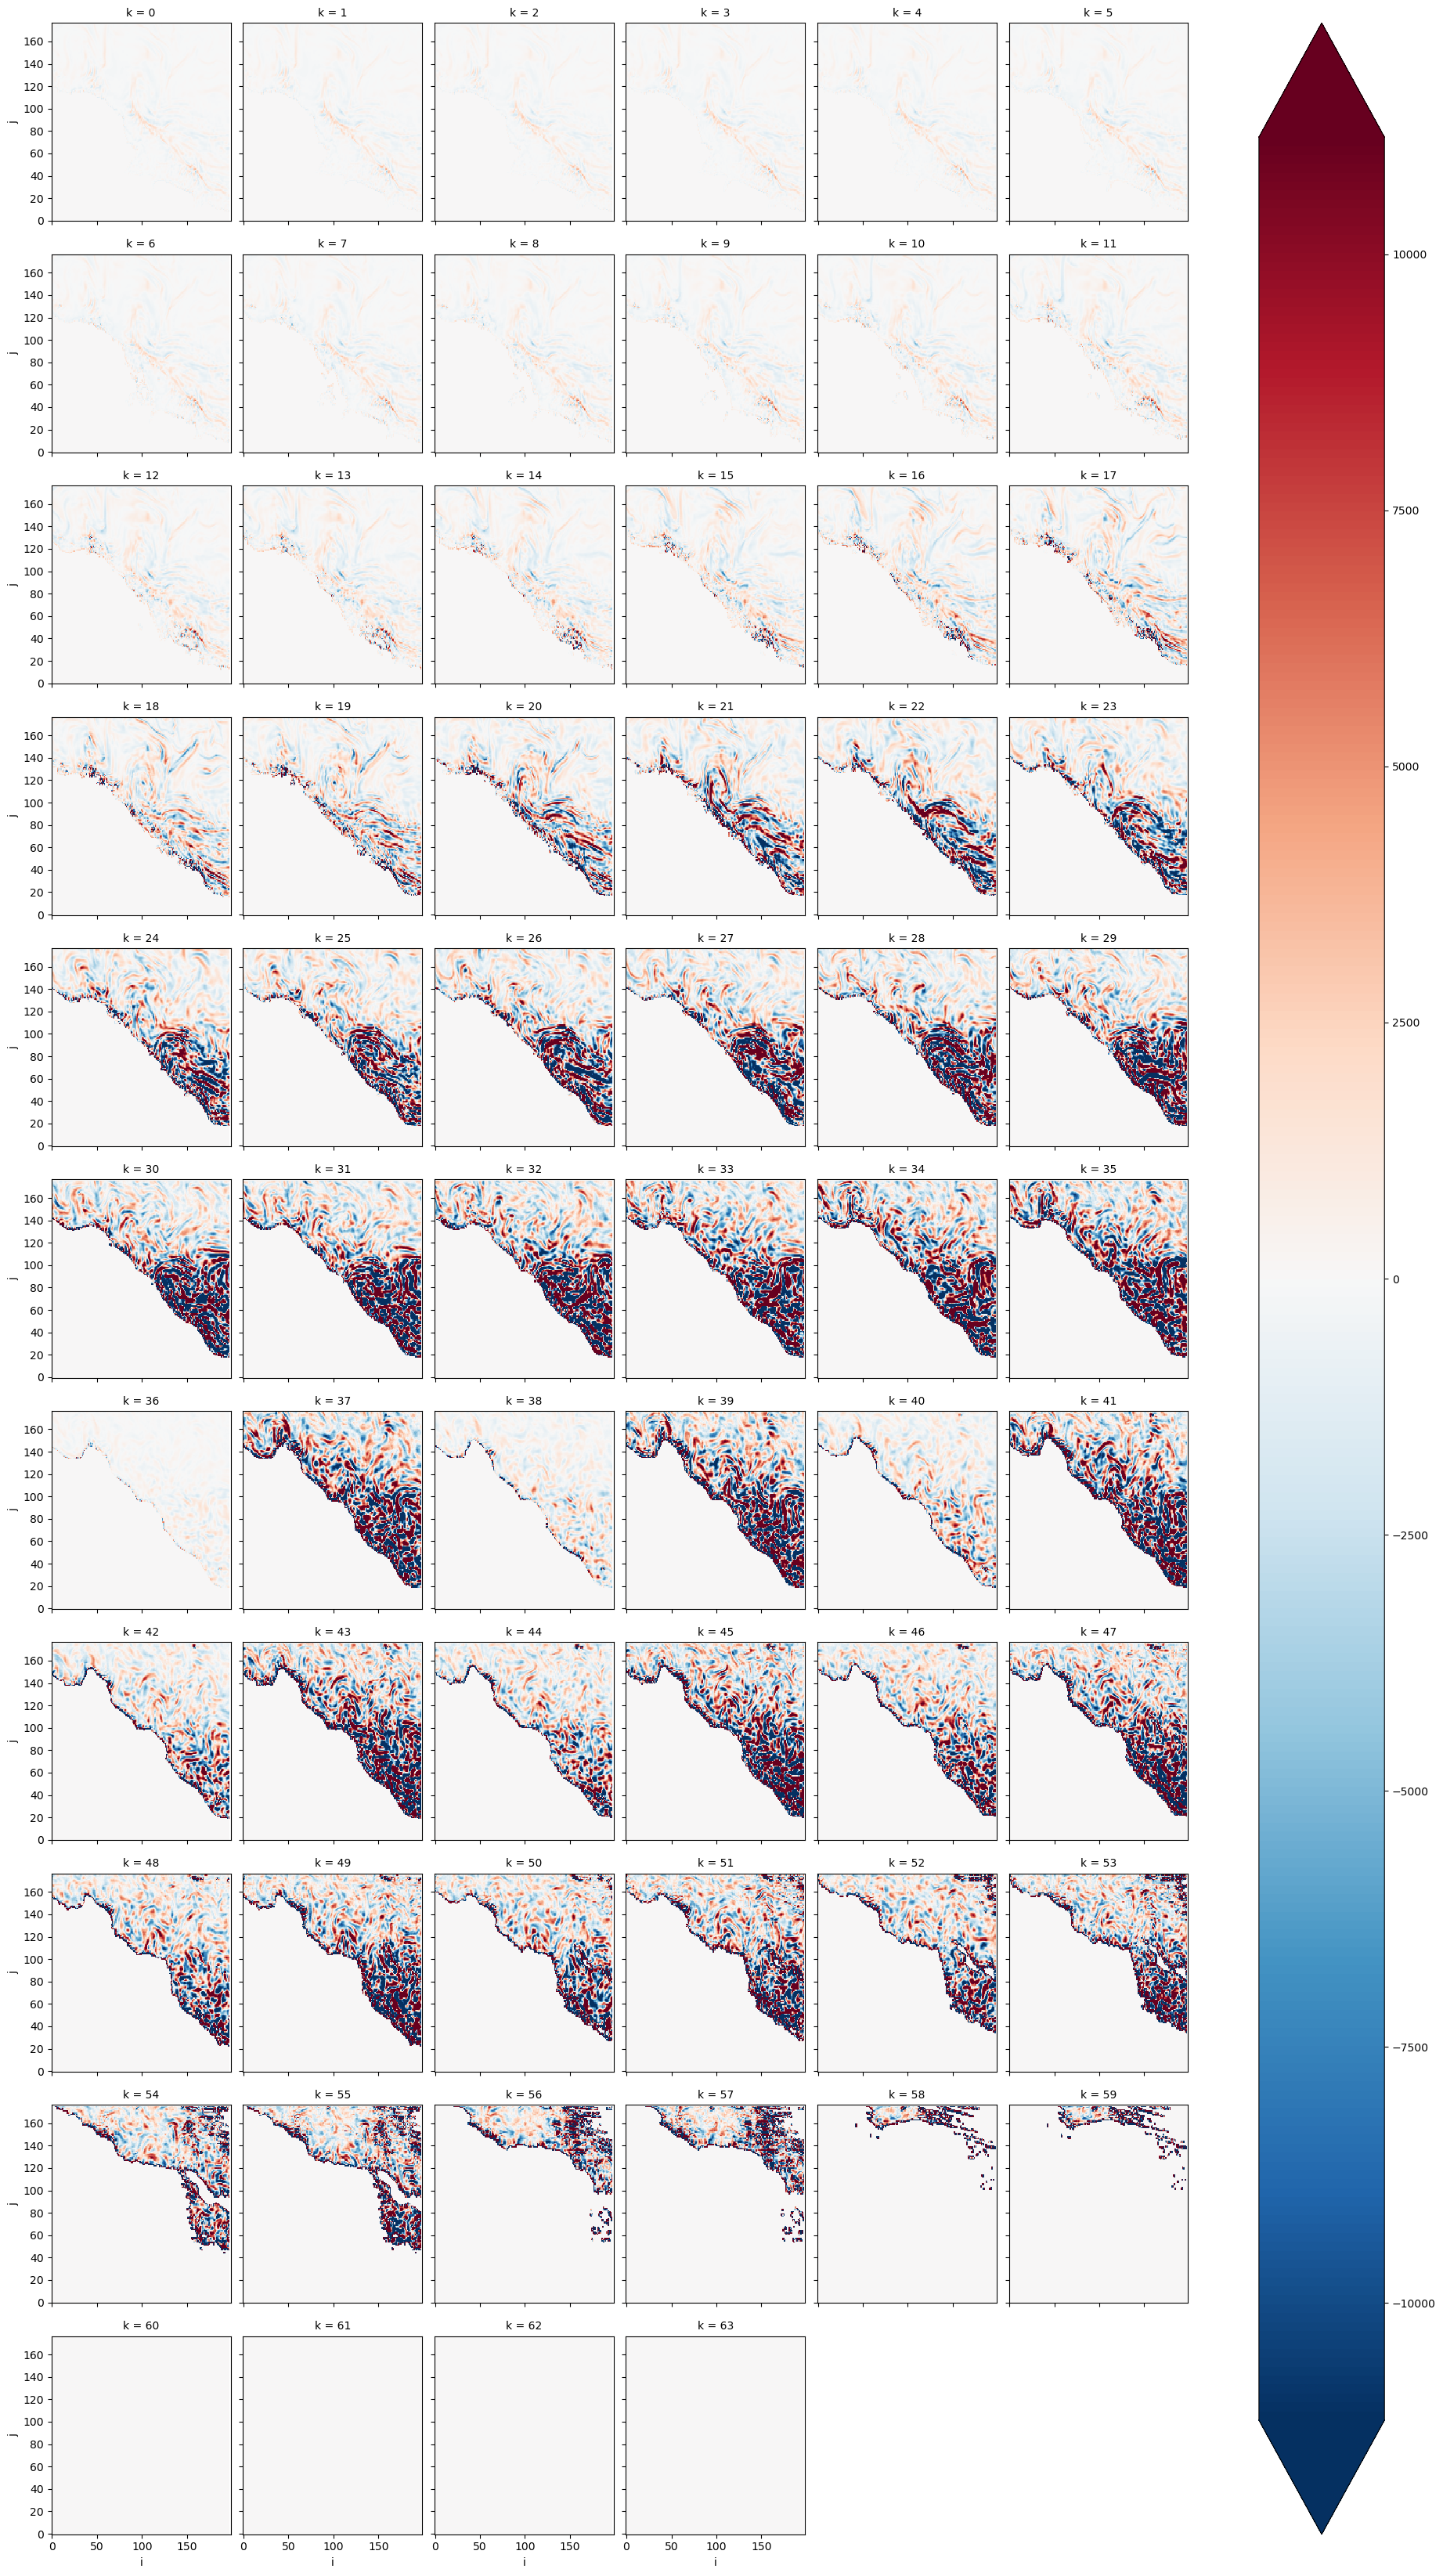

In [35]:
F_uv_vol = (
    ds.u * ds.dy_t * ds.dz_t - ds.u.shift(i=-1)* ds.dy_t * ds.dz_t 
    + ds.v * ds.dx_t * ds.dz_t - ds.v.shift(j=-1) * ds.dx_t * ds.dz_t
)
F_uv_vol.isel(time=0).plot(x='i',y='j',col='k',col_wrap=6, robust=True)

In [49]:
# dw_by_dz = F_uv_vol/ds.dx_t/ds.dy_t/ds.dz_t

# integrand = -div_flux.isel(k=slice(0, -1)) # we drop the last layer

# dz_3d_mid = dz_3d.isel(k=slice(0, -1))
# integrand = integrand * dz_3d_mid

# # Reverse for bottom-up integration
# w_bottom_up = integrand.isel(k=slice(None, None, -1)).cumsum(dim='k', skipna=True)

integrand = -F_uv_vol * ds.dz_t
w_cs = integrand.isel(k=slice(None, None, -1)).cumsum('k').where(ds.tmask==1)
area = ds.dx_t * ds.dy_t

In [50]:
w = w_cs / area

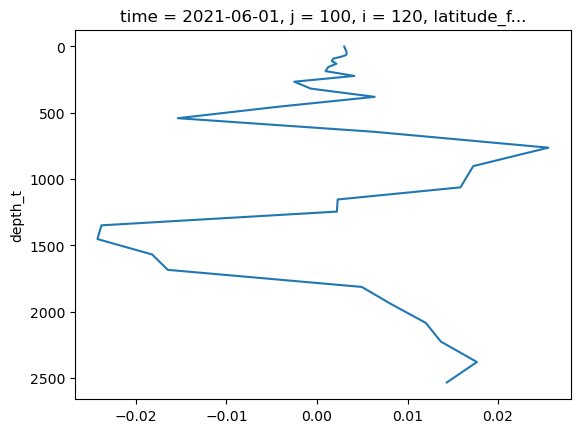

In [51]:
w.isel(i=120,j=100,time=0).plot(y='depth_t')
plt.gca().invert_yaxis()